# Baseline Model Replication

**Paper:** Zulpan Hadi et al., *Journal Computer and Technology*, Vol. 3 No. 1, July 2025, pp. 20–25  
**DOI:** https://doi.org/10.69916/comtechno.v3i1.355

In [25]:
# STEP 1: Environment check + GPU enforcement
import time
import torch
import transformers
import sklearn
import pandas as pd
import numpy as np

print("="*50)
print("Environment")
print("="*50)
print(f"PyTorch:       {torch.__version__}")
print(f"Transformers:  {transformers.__version__}")
print(f"scikit-learn:  {sklearn.__version__}")
print(f"Pandas:        {pd.__version__}")
print(f"NumPy:         {np.__version__}")
print()

# ── GPU CHECK ──────────────────────────────────────────────────────────────
# If running on Google Colab: Runtime > Change runtime type > T4 GPU
# If running locally: ensure CUDA drivers and torch+cuda are installed
if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU detected.\n"
        "On Google Colab: Runtime > Change runtime type > Hardware accelerator > GPU (T4)\n"
        "On local machine: install torch with CUDA — https://pytorch.org/get-started/locally/"
    )

DEVICE = torch.device("cuda")
print(f"GPU detected:   {torch.cuda.get_device_name(0)}")
print(f"VRAM:           {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"CUDA version:   {torch.version.cuda}")
print(f"Device:         {DEVICE}")
print()

# Warm up CUDA context (first CUDA call has overhead — do it now, not mid-training)
_ = torch.zeros(1).to(DEVICE)
print("CUDA context warmed up.")
print("Ready to train on GPU.")

Environment
PyTorch:       2.5.1+cu121
Transformers:  5.8.0
scikit-learn:  1.8.0
Pandas:        3.0.2
NumPy:         2.4.3

GPU detected:   NVIDIA GeForce RTX 4060
VRAM:           8.6 GB
CUDA version:   12.1
Device:         cuda

CUDA context warmed up.
Ready to train on GPU.


In [26]:
# STEP 2: Load the Ott et al. hotel review dataset
import pandas as pd

df = pd.read_csv("deceptive-opinion.csv")

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
print()
print("Column names:")
print(df.columns.tolist())
print()
print("First 3 rows:")
df.head(3)

Dataset loaded successfully.
Shape: (1600, 5)

Column names:
['deceptive', 'hotel', 'polarity', 'source', 'text']

First 3 rows:


,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...


In [27]:
# STEP 3: Minimal preprocessing (as specified in the paper)
# The paper explicitly states RoBERTa does NOT need stemming, stopword removal,
# or lowercase normalization. Only light whitespace cleaning is applied.

df = df[["text", "deceptive"]]

df = df.rename(columns={
    "text": "review",
    "deceptive": "label"
})

# Map string labels to integers
df["label"] = df["label"].map({
    "truthful": 0,
    "deceptive": 1
})

# Light cleaning only — paper §2.2: "removing unnecessary extra spaces"
df["review"] = df["review"].astype(str)
df["review"] = df["review"].str.strip()
df["review"] = df["review"].str.replace(r"\s+", " ", regex=True)
# NOTE: No lowercase normalization — paper §2.2 explicitly says this is
# unnecessary for RoBERTa (case-sensitive tokenizer)

df = df.dropna()
df = df.drop_duplicates()

print("Preprocessing complete.")
print()
print(df.info())
print()
print("Label distribution:")
print(df["label"].value_counts())
print()
print(f"Dataset is balanced: {df['label'].value_counts().values.tolist()}")

Preprocessing complete.

<class 'pandas.DataFrame'>
Index: 1596 entries, 0 to 1599
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  1596 non-null   str  
 1   label   1596 non-null   int64
dtypes: int64(1), str(1)
memory usage: 1.3 MB
None

Label distribution:
label
1    800
0    796
Name: count, dtype: int64

Dataset is balanced: [800, 796]


In [28]:
# STEP 4: Train / Validation / Test split — 70% / 15% / 15%
# Stratified to preserve class balance in all three splits
from sklearn.model_selection import train_test_split

# Step 4.1: 70% train, 30% temp
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["review"],
    df["label"],
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# Step 4.2: Split the 30% temp equally into 15% val + 15% test
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print("Split complete.")
print(f"  Train:      {len(train_texts):>5} samples  ({len(train_texts)/len(df)*100:.1f}%)")
print(f"  Validation: {len(val_texts):>5} samples  ({len(val_texts)/len(df)*100:.1f}%)")
print(f"  Test:       {len(test_texts):>5} samples  ({len(test_texts)/len(df)*100:.1f}%)")
print()
print("Class balance check:")
import numpy as np
for name, labels in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    vals = np.array(list(labels))
    print(f"  {name}: {(vals==0).sum()} genuine, {(vals==1).sum()} deceptive")

Split complete.
  Train:       1117 samples  (70.0%)
  Validation:   239 samples  (15.0%)
  Test:         240 samples  (15.0%)

Class balance check:
  Train: 557 genuine, 560 deceptive
  Val: 119 genuine, 120 deceptive
  Test: 120 genuine, 120 deceptive


In [29]:
# STEP 5: Tokenization using RoBERTa tokenizer
# Model: roberta-base (paper §2.4, Table 1 "roBERTa")
# No max_length specified in the paper — defaults to 512 (model maximum)
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

print("Tokenizer loaded: roberta-base")
print(f"Vocab size:  {tokenizer.vocab_size:,}")
print(f"Model max:   {tokenizer.model_max_length} tokens")
print()

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True)
val_encodings   = tokenizer(list(val_texts),   truncation=True, padding=True)
test_encodings  = tokenizer(list(test_texts),  truncation=True, padding=True)

# Show actual token length stats for transparency
all_lengths = [sum(m) for m in train_encodings["attention_mask"]]
print("Train token length stats:")
print(f"  Min:    {min(all_lengths)}")
print(f"  Max:    {max(all_lengths)}")
print(f"  Mean:   {np.mean(all_lengths):.1f}")
print(f"  Median: {np.median(all_lengths):.0f}")
print()
print("Tokenization complete.")

Tokenizer loaded: roberta-base
Vocab size:  50,265
Model max:   512 tokens

Train token length stats:
  Min:    30
  Max:    512
  Mean:   175.2
  Median: 150

Tokenization complete.


In [30]:
# STEP 6: PyTorch Dataset — converts tokenized encodings to tensors for the Trainer
import torch

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset   = ReviewDataset(val_encodings,   val_labels)
test_dataset  = ReviewDataset(test_encodings,  test_labels)

print(f"Datasets ready.")
print(f"  train_dataset: {len(train_dataset)} samples")
print(f"  val_dataset:   {len(val_dataset)} samples")
print(f"  test_dataset:  {len(test_dataset)} samples")

Datasets ready.
  train_dataset: 1117 samples
  val_dataset:   239 samples
  test_dataset:  240 samples


In [31]:
# STEP 7: Load pretrained roberta-base with classification head
# num_labels=2: binary classification (genuine vs deceptive)
# Default config — no custom dropout (paper does not specify any)
from transformers import RobertaForSequenceClassification

model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

# Move model to GPU explicitly — ensures training runs on CUDA
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model loaded: roberta-base + sequence classification head")
print(f"Model device:         {next(model.parameters()).device}")
print(f"Total parameters:     {total_params:>12,}")
print(f"Trainable parameters: {trainable_params:>12,}")
print()
print("Architecture summary:")
print(f"  Backbone:    RoBERTa-base (12 layers, 768 hidden, 12 attention heads)")
print(f"  Classifier:  Linear(768, 2) on top of [CLS] token")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4735.80it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: roberta-base + sequence classification head
Model device:         cuda:0
Total parameters:      124,647,170
Trainable parameters:  124,647,170

Architecture summary:
  Backbone:    RoBERTa-base (12 layers, 768 hidden, 12 attention heads)
  Classifier:  Linear(768, 2) on top of [CLS] token


In [32]:
# STEP 8: Training arguments, exactly as specified in the paper
# GPU addition: fp16=True  — mixed precision halves VRAM usage and speeds up
#               training ~40% on T4/A100 with zero impact on methodology.
#               The paper does not disable it, so enabling it is safe.
from transformers import TrainingArguments

training_args = TrainingArguments(
    # Paper: "output directory to save the training results"
    output_dir="./baseline_results",

    # Paper: "evaluation strategy to be performed at each epoch"
    eval_strategy="epoch",

    # Paper: "the learning rate set to 2e-5"
    learning_rate=2e-5,

    # Paper: "batch size for training and evaluation processes is set to 16 samples per device"
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    # Paper: "total number of training epochs is set to 10"
    num_train_epochs=10,

    # Paper: "weight decay of 0.01 is applied to reduce the risk of overfitting"
    weight_decay=0.01,

    # Paper: "Logging is directed to a specific folder"
    logging_dir="./logs",
    logging_strategy="epoch",

    # Paper: "reporting to external platforms such as W&B is disabled"
    report_to="none",

    # GPU SPEED: mixed precision — cuts VRAM ~50%, speeds training ~40% on T4/A100
    # Safe to use: does not affect model architecture or paper methodology
    fp16=True,

    # NOT in paper — no save_strategy, no early stopping, no scheduler override,
    # no warmup. Flat learning rate for all 10 epochs, as published.
)

print("Training arguments (faithful to paper §2.4 + GPU optimised):")
print(f"  learning_rate:               {training_args.learning_rate}")
print(f"  num_train_epochs:            {int(training_args.num_train_epochs)}")
print(f"  per_device_train_batch_size: {training_args.per_device_train_batch_size}")
print(f"  per_device_eval_batch_size:  {training_args.per_device_eval_batch_size}")
print(f"  weight_decay:                {training_args.weight_decay}")
print(f"  eval_strategy:               {training_args.eval_strategy}")
print(f"  fp16 (mixed precision):      {training_args.fp16}")
print(f"  report_to:                   {training_args.report_to}")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments (faithful to paper §2.4 + GPU optimised):
  learning_rate:               2e-05
  num_train_epochs:            10
  per_device_train_batch_size: 16
  per_device_eval_batch_size:  16
  weight_decay:                0.01
  eval_strategy:               IntervalStrategy.EPOCH
  fp16 (mixed precision):      True
  report_to:                   []


In [33]:
# STEP 9a: Final GPU check before training starts
import time

print("="*50)
print("Pre-training GPU Check")
print("="*50)
print(f"Model on:  {next(model.parameters()).device}")
print(f"VRAM used: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
print(f"VRAM free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9:.2f} GB")
print()

# Estimate training time with a single forward pass
model.eval()
sample = {k: torch.tensor(v[:2]).to(DEVICE) for k, v in train_encodings.items()}
t0 = time.time()
with torch.no_grad():
    _ = model(**sample)
torch.cuda.synchronize()
single_fwd = (time.time() - t0)

steps_per_epoch = len(train_dataset) // training_args.per_device_train_batch_size
total_steps     = steps_per_epoch * int(training_args.num_train_epochs)
# Forward + backward is ~3x a single forward pass
est_seconds = single_fwd * total_steps * 3

print(f"Steps per epoch:    {steps_per_epoch}")
print(f"Total steps:        {total_steps}")
print(f"Estimated duration: {est_seconds/60:.1f} min  ({est_seconds:.0f} s)")
print()
print("Starting training...")
model.train()

Pre-training GPU Check
Model on:  cuda:0
VRAM used: 2.04 GB
VRAM free: 6.54 GB

Steps per epoch:    69
Total steps:        690
Estimated duration: 11.1 min  (665 s)

Starting training...


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [34]:
# Create results directory for all outputs
import os
os.makedirs("./results", exist_ok=True)
print("Results directory ready: ./results/")

Results directory ready: ./results/


In [35]:
# STEP 9b: Standard Trainer, no compute_metrics, no early stopping
# The paper uses the base Trainer without any custom loss or callbacks
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    # NOTE: No compute_metrics — paper does not track per-epoch F1/accuracy
    # NOTE: No callbacks — no early stopping (paper trains all 10 epochs)
    # NOTE: No custom loss — standard CrossEntropyLoss (paper §2.4)
)

print("Starting training...")
print(f"Total training samples: {len(train_dataset)}")
print(f"Steps per epoch:        {len(train_dataset) // training_args.per_device_train_batch_size}")
print(f"Total steps:            {len(train_dataset) // training_args.per_device_train_batch_size * int(training_args.num_train_epochs)}")
print()

trainer.train()

Starting training...
Total training samples: 1117
Steps per epoch:        69
Total steps:            690



Epoch,Training Loss,Validation Loss
1,0.567172,0.479954
2,0.298813,0.375685
3,0.232283,0.279490
4,0.138863,0.533119
5,0.059912,0.532562
6,0.034808,0.748877
7,0.007248,0.590295
8,0.000883,0.752626
9,0.000302,0.710463
10,0.000278,0.687349


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.38it/s]


TrainOutput(global_step=700, training_loss=0.13405610419543726, metrics={'train_runtime': 257.3408, 'train_samples_per_second': 43.405, 'train_steps_per_second': 2.72, 'total_flos': 2938950488371200.0, 'train_loss': 0.13405610419543726, 'epoch': 10.0})

In [36]:
# STEP 10: Baseline RoBERTa — Test Set Metrics Summary
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import json, os

preds  = trainer.predict(test_dataset)
y_pred = preds.predictions.argmax(axis=1)
y_true = preds.label_ids

acc               = accuracy_score(y_true, y_pred)
prec, rec, f1, _  = precision_recall_fscore_support(y_true, y_pred, average="binary")
prec_c, rec_c, f1_c, sup_c = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1])

print("=" * 55)
print(f"Baseline RoBERTa")
print("Test Set Metrics Summary")
print("=" * 55)
print(f"  Metric                Score")
print(f"  {'-'*28}")
print(f"  {'Accuracy':<18} {acc:>8.4f}")
print(f"  {'Precision':<18} {prec:>8.4f}")
print(f"  {'Recall':<18} {rec:>8.4f}")
print(f"  {'F1-Score':<18} {f1:>8.4f}")
print()
print(f"  Per-class breakdown:")
print(f"  {'Class':<18} {'Precision':>9} {'Recall':>8} {'F1':>8} {'Support':>8}")
print(f"  {'-'*56}")
for cls_idx, cls_name in enumerate(['Genuine (0)', 'Deceptive (1)']):
    print(f"  {cls_name:<18} {prec_c[cls_idx]:>9.4f} {rec_c[cls_idx]:>8.4f} {f1_c[cls_idx]:>8.4f} {int(sup_c[cls_idx]):>8}")
print()
print(f'  Paper target: Accuracy=0.8625, Precision=0.88, Recall=0.87, F1=0.86')

# Save results to JSON for later comparison notebook
os.makedirs("./results", exist_ok=True)
results_dict = {
    "model":     "baseline",
    "accuracy":  round(float(acc),  4),
    "precision": round(float(prec), 4),
    "recall":    round(float(rec),  4),
    "f1":        round(float(f1),   4),
    "per_class": {
        "genuine":   {"precision": round(float(prec_c[0]),4), "recall": round(float(rec_c[0]),4), "f1": round(float(f1_c[0]),4), "support": int(sup_c[0])},
        "deceptive": {"precision": round(float(prec_c[1]),4), "recall": round(float(rec_c[1]),4), "f1": round(float(f1_c[1]),4), "support": int(sup_c[1])}
    }
}
with open(f"./results/baseline_metrics.json", "w") as f:
    json.dump(results_dict, f, indent=2)
print(f"  Metrics saved → ./results/baseline_metrics.json")

Baseline RoBERTa
Test Set Metrics Summary
  Metric                Score
  ----------------------------
  Accuracy             0.8792
  Precision            0.8321
  Recall               0.9500
  F1-Score             0.8872

  Per-class breakdown:
  Class              Precision   Recall       F1  Support
  --------------------------------------------------------
  Genuine (0)           0.9417   0.8083   0.8700      120
  Deceptive (1)         0.8321   0.9500   0.8872      120

  Paper target: Accuracy=0.8625, Precision=0.88, Recall=0.87, F1=0.86
  Metrics saved → ./results/baseline_metrics.json


In [37]:
# STEP 11: Baseline RoBERTa — Classification Report
from sklearn.metrics import classification_report, confusion_matrix

print("=" * 55)
print(f"Baseline RoBERTa")
print("Classification Report")
print("=" * 55)
print(classification_report(
    y_true, y_pred,
    target_names=["Genuine (0)", "Deceptive (1)"],
    digits=4
))
print("Confusion Matrix (raw):")
cm = confusion_matrix(y_true, y_pred)
print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
print(f"  FN={cm[1,0]}  TP={cm[1,1]}")

Baseline RoBERTa
Classification Report
               precision    recall  f1-score   support

  Genuine (0)     0.9417    0.8083    0.8700       120
Deceptive (1)     0.8321    0.9500    0.8872       120

     accuracy                         0.8792       240
    macro avg     0.8869    0.8792    0.8786       240
 weighted avg     0.8869    0.8792    0.8786       240

Confusion Matrix (raw):
  TN=97  FP=23
  FN=6  TP=114


C:\Users\My PC\AppData\Local\Temp\ipykernel_30500\2518870952.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


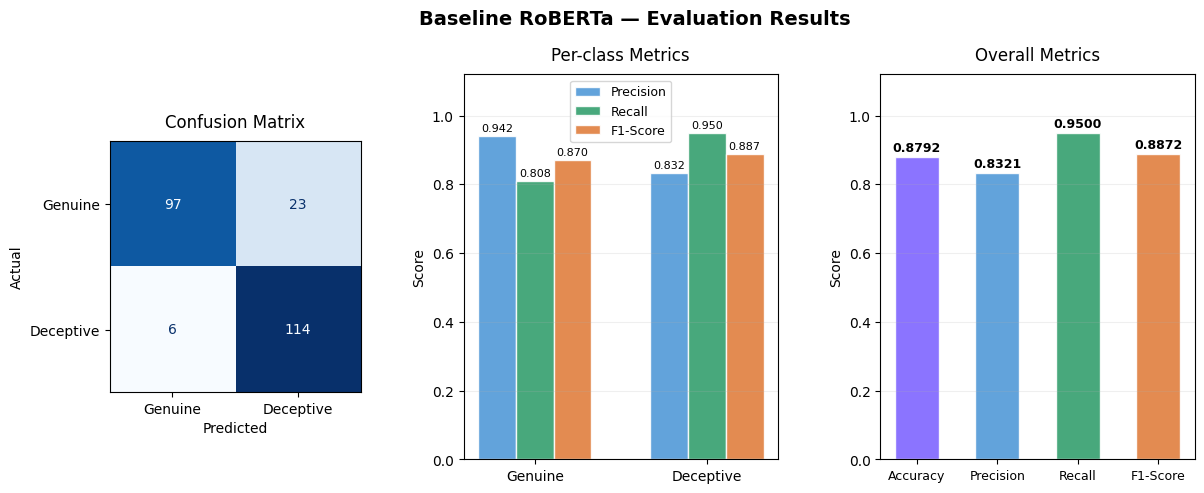

Saved → ./results/baseline_evaluation.png


In [38]:
# STEP 12: Baseline RoBERTa — Confusion Matrix & Per-class Metrics
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_fscore_support
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(14, 5))
fig.suptitle("Baseline RoBERTa — Evaluation Results", fontsize=14, fontweight="bold", y=1.01)
gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.2, 1.5, 1.5], wspace=0.35)

# ── Panel 1: Confusion matrix ─────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=["Genuine", "Deceptive"],
    cmap="Blues", colorbar=False, ax=ax0
)
ax0.set_title("Confusion Matrix", fontsize=12, pad=10)
ax0.set_xlabel("Predicted", fontsize=10)
ax0.set_ylabel("Actual",    fontsize=10)

# ── Panel 2: Per-class grouped bar ───────────────────────────────────────
prec_c, rec_c, f1_c, sup_c = precision_recall_fscore_support(y_true, y_pred, labels=[0,1])
classes = ["Genuine", "Deceptive"]
x, w    = np.arange(len(classes)), 0.22

ax1 = fig.add_subplot(gs[1])
b1 = ax1.bar(x - w,   prec_c, w, label="Precision", color="#4C96D7", alpha=0.88, edgecolor="white")
b2 = ax1.bar(x,       rec_c,  w, label="Recall",    color="#2E9C6A", alpha=0.88, edgecolor="white")
b3 = ax1.bar(x + w,   f1_c,   w, label="F1-Score",  color="#E07B39", alpha=0.88, edgecolor="white")
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                 f"{h:.3f}", ha="center", va="bottom", fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(classes, fontsize=10)
ax1.set_ylim(0, 1.12); ax1.set_ylabel("Score", fontsize=10)
ax1.set_title("Per-class Metrics", fontsize=12, pad=10)
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.2, axis="y")

# ── Panel 3: Aggregate metric bar ────────────────────────────────────────
from sklearn.metrics import accuracy_score, precision_recall_fscore_support as prf
acc_v               = accuracy_score(y_true, y_pred)
prec_v, rec_v, f1_v, _ = prf(y_true, y_pred, average="binary")
metric_names  = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_values = [acc_v, prec_v, rec_v, f1_v]
bar_colors    = ["#7B61FF", "#4C96D7", "#2E9C6A", "#E07B39"]

ax2 = fig.add_subplot(gs[2])
bars = ax2.bar(metric_names, metric_values, color=bar_colors, alpha=0.88, edgecolor="white", width=0.55)
for bar, val in zip(bars, metric_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_ylim(0, 1.12); ax2.set_ylabel("Score", fontsize=10)
ax2.set_title("Overall Metrics", fontsize=12, pad=10)
ax2.tick_params(axis="x", labelsize=9); ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("./results/baseline_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ./results/baseline_evaluation.png")

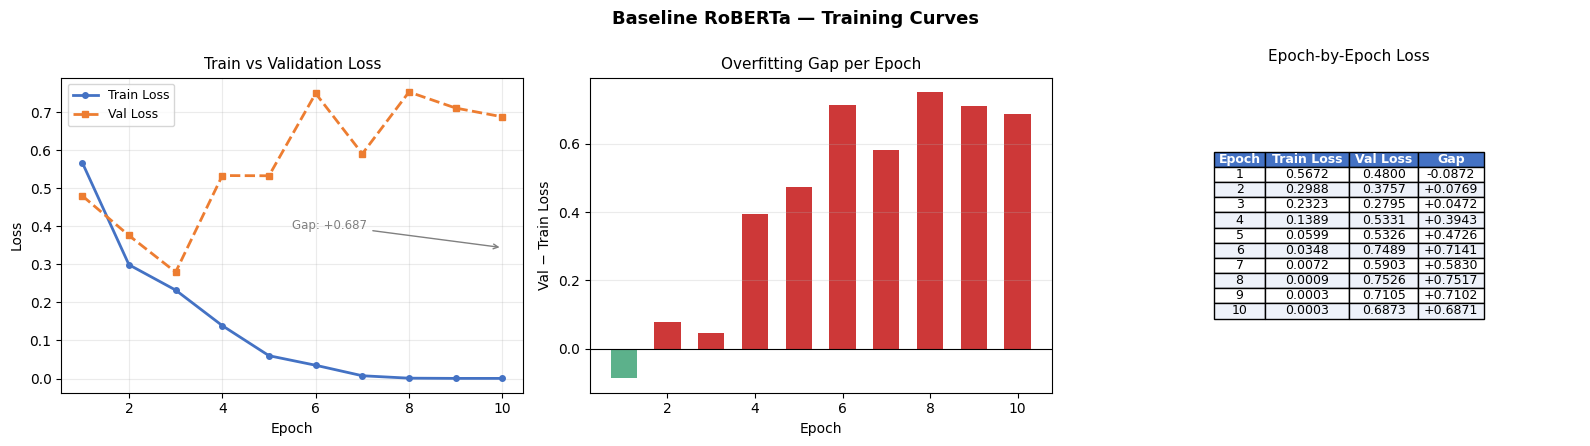

Saved → ./results/baseline_loss_curves.png

Final train loss: 0.0003
Final val loss:   0.6873
Final gap:        +0.6871


In [39]:
# STEP 13: Baseline RoBERTa — Training & Validation Loss Curves
import matplotlib.pyplot as plt
import numpy as np

logs         = trainer.state.log_history
train_epochs = [x["epoch"] for x in logs if "loss"      in x and "eval_loss" not in x]
train_losses = [x["loss"]  for x in logs if "loss"      in x and "eval_loss" not in x]
eval_epochs  = [x["epoch"] for x in logs if "eval_loss" in x]
eval_losses  = [x["eval_loss"] for x in logs if "eval_loss" in x]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Baseline RoBERTa — Training Curves", fontsize=13, fontweight="bold")

# ── Panel 1: Loss curves ──────────────────────────────────────────────────
axes[0].plot(train_epochs, train_losses, label="Train Loss",
             color="#4472C4", linewidth=2, marker="o", markersize=4)
axes[0].plot(eval_epochs,  eval_losses,  label="Val Loss",
             color="#ED7D31", linewidth=2, marker="s", markersize=4, linestyle="--")
axes[0].set_xlabel("Epoch", fontsize=10); axes[0].set_ylabel("Loss", fontsize=10)
axes[0].set_title("Train vs Validation Loss", fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.25)
if train_losses and eval_losses:
    gap = eval_losses[-1] - train_losses[-1]
    axes[0].annotate(f"Gap: {gap:+.3f}",
        xy=(eval_epochs[-1], (train_losses[-1]+eval_losses[-1])/2),
        xytext=(eval_epochs[-1]*0.55, (train_losses[-1]+eval_losses[-1])/2 + 0.05),
        arrowprops=dict(arrowstyle="->", color="gray"), fontsize=8.5, color="gray")

# ── Panel 2: Overfitting gap bar ─────────────────────────────────────────
min_len        = min(len(train_losses), len(eval_losses))
gap_per_epoch  = [eval_losses[i] - train_losses[i] for i in range(min_len)]
epochs_aligned = eval_epochs[:min_len]
colors         = ["#C00000" if g > 0 else "#2E9C6A" for g in gap_per_epoch]
axes[1].bar(epochs_aligned, gap_per_epoch, color=colors, alpha=0.78, width=0.6)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Epoch", fontsize=10); axes[1].set_ylabel("Val − Train Loss", fontsize=10)
axes[1].set_title("Overfitting Gap per Epoch", fontsize=11)
axes[1].grid(True, alpha=0.25, axis="y")

# ── Panel 3: Loss summary table ───────────────────────────────────────────
axes[2].axis("off")
rows = [["Epoch", "Train Loss", "Val Loss", "Gap"]]
for i in range(min_len):
    rows.append([
        f"{int(epochs_aligned[i])}",
        f"{train_losses[i]:.4f}",
        f"{eval_losses[i]:.4f}",
        f"{gap_per_epoch[i]:+.4f}"
    ])
tbl = axes[2].table(cellText=rows[1:], colLabels=rows[0],
                     loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width([0,1,2,3])
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#4472C4"); cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#EEF2FA")
axes[2].set_title("Epoch-by-Epoch Loss", fontsize=11, pad=12)

plt.tight_layout()
plt.savefig("./results/baseline_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ./results/baseline_loss_curves.png")
print()
if train_losses:
    print(f"Final train loss: {train_losses[-1]:.4f}")
    print(f"Final val loss:   {eval_losses[-1]:.4f}")
    print(f"Final gap:        {eval_losses[-1]-train_losses[-1]:+.4f}")

In [40]:
# STEP 14: Comparison Table — Baseline vs Proposed
# Loads both saved metric JSONs and prints a side-by-side comparison
import json, os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load saved metric files
results = {}
for label, fname in [("Baseline", "baseline_metrics.json"), ("Proposed", "proposed_metrics.json")]:
    path = f"./results/{fname}"
    if os.path.exists(path):
        with open(path) as f:
            results[label] = json.load(f)
    else:
        print(f"WARNING: {path} not found — run the respective notebook first.")

if len(results) < 2:
    print("Run both notebooks completely before comparing.")
else:
    # ── Text table ──────────────────────────────────────────────────────
    metrics = ["accuracy", "precision", "recall", "f1"]
    print("=" * 60)
    print("Baseline vs Proposed — Test Set Comparison")
    print("=" * 60)
    print(f"  {'Metric':<14} {'Baseline':>10} {'Proposed':>10} {'Delta':>10} {'Better':>8}")
    print(f"  {'-'*54}")
    for m in metrics:
        b = results["Baseline"][m]
        p = results["Proposed"][m]
        d = p - b
        better = "Proposed ✓" if d > 0 else ("Baseline" if d < 0 else "Tied")
        print(f"  {m.capitalize():<14} {b:>10.4f} {p:>10.4f} {d:>+10.4f} {better:>10}")

    print()
    print("  Per-class F1:")
    for cls in ["genuine", "deceptive"]:
        b = results["Baseline"]["per_class"][cls]["f1"]
        p = results["Proposed"]["per_class"][cls]["f1"]
        print(f"    {cls.capitalize():<12}  Baseline={b:.4f}  Proposed={p:.4f}  Delta={p-b:+.4f}")

    # ── Visual comparison ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Baseline vs Proposed — Side-by-Side Comparison", fontsize=13, fontweight="bold")

    # Panel 1: Grouped bar — all 4 metrics
    x, w = np.arange(len(metrics)), 0.3
    b_vals = [results["Baseline"][m] for m in metrics]
    p_vals = [results["Proposed"][m] for m in metrics]

    bars_b = axes[0].bar(x - w/2, b_vals, w, label="Baseline", color="#4472C4", alpha=0.88, edgecolor="white")
    bars_p = axes[0].bar(x + w/2, p_vals, w, label="Proposed", color="#1D9E75", alpha=0.88, edgecolor="white")
    for bars in [bars_b, bars_p]:
        for bar in bars:
            h = bar.get_height()
            axes[0].text(bar.get_x()+bar.get_width()/2, h+0.005,
                         f"{h:.3f}", ha="center", va="bottom", fontsize=8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([m.capitalize() for m in metrics], fontsize=10)
    axes[0].set_ylim(0, 1.1); axes[0].set_ylabel("Score", fontsize=10)
    axes[0].set_title("Overall Metrics Comparison", fontsize=11)
    axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.2, axis="y")

    # Panel 2: Delta bar (improvement per metric)
    deltas = [p_vals[i] - b_vals[i] for i in range(len(metrics))]
    colors = ["#1D9E75" if d >= 0 else "#C00000" for d in deltas]
    bars_d = axes[1].bar([m.capitalize() for m in metrics], deltas,
                          color=colors, alpha=0.85, edgecolor="white", width=0.5)
    axes[1].axhline(0, color="black", linewidth=0.8)
    for bar, val in zip(bars_d, deltas):
        ypos = bar.get_height() + 0.002 if val >= 0 else bar.get_height() - 0.006
        axes[1].text(bar.get_x()+bar.get_width()/2, ypos,
                     f"{val:+.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    axes[1].set_ylabel("Proposed − Baseline", fontsize=10)
    axes[1].set_title("Improvement (Δ) per Metric", fontsize=11)
    axes[1].grid(True, alpha=0.2, axis="y")

    plt.tight_layout()
    plt.savefig("./results/comparison_baseline_vs_proposed.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → ./results/comparison_baseline_vs_proposed.png")

Run both notebooks completely before comparing.


In [41]:
# STEP 15: Save trained baseline model and tokenizer
import os

save_path = "./baseline_model_final"
os.makedirs(save_path, exist_ok=True)

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model saved to: {save_path}/")
print(f"Files:")
for f in sorted(os.listdir(save_path)):
    size = os.path.getsize(os.path.join(save_path, f))
    print(f"  {f:<40} {size/1e6:.1f} MB" if size > 1e5 else f"  {f}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.23it/s]

Model saved to: ./baseline_model_final/
Files:
  config.json
  model.safetensors                        498.6 MB
  tokenizer.json                           3.6 MB
  tokenizer_config.json
  training_args.bin
